<hr style="border: 4px solid #2e7d32;">

**<h1 style="font-size:36px;">📊 HOMEWORK WEEK 3 - EDA DAN DATA VISUALIZATION</h1>**

<hr style="border: 4px solid #2e7d32;">

**Link Dataset : [Global AI Adoption Dataset](https://www.kaggle.com/datasets/mohankrishnathalla/global-ai-adoption-and-workforce-impact-dataset)**

Dataset yang digunakan dalam analisis ini adalah *Global AI Adoption Dataset* yang berisi informasi terkait tingkat adopsi AI pada berbagai sektor, negara, serta faktor-faktor yang mempengaruhinya. Tujuan dari EDA ini adalah untuk memahami pola data, distribusi variabel, serta hubungan antar fitur yang dapat digunakan untuk analisis lebih lanjut.

<table style="font-size:18px; border-collapse: collapse; width: 60%;">
  <tr>
    <td colspan="2" style="font-weight:bold; font-size:22px; background-color:#f2f2f2; padding:8px;">
    👩🏻‍🎓 Identitas Mahasiswa
    </td>
  </tr>
  <tr>
    <td style="font-weight:bold; width: 150px; padding:6px;">Nama</td>
    <td style="padding:6px;">: Anila Dwi Lestari</td>
  </tr>
  <tr>
    <td style="font-weight:bold; padding:6px;">NIM</td>
    <td style="padding:6px;">: 203012520036</td>
  </tr>
</table>

<hr style="border: 4px solid #2e7d32;">

**<h1 style="font-size:36px;">🤖 GLOBAL AI ADOPTION & WORKFORCE IMPACT DATASET</h1>**

<hr style="border: 4px solid #2e7d32;">

Dataset Global AI Adoption & Workforce Impact terdiri dari tiga file CSV utama, yaitu ai_company_adoption.csv, ai_industry_summary.csv, dan country_ai_index.csv. Secara keseluruhan, dataset ini memiliki total **150.039 baris data dan 59 kolom fitur** berdasarkan gabungan struktur dari ketiga file tersebut. File **ai_company_adoption.csv** merupakan dataset utama yang berisi **150.000 baris dan 43 kolom**, di mana setiap baris merepresentasikan hasil survei tingkat perusahaan yang mencakup perilaku adopsi Artificial Intelligence (AI), dampaknya terhadap tenaga kerja, perubahan operasional, serta aspek tata kelola perusahaan. Sementara itu, **ai_industry_summary.csv** merupakan dataset agregasi pada level industri dengan **9 baris dan 8 kolom** yang digunakan untuk analisis benchmarking antar sektor. Selain itu, **country_ai_index.csv** berisi data tingkat negara dengan **30 baris dan 8 kolom**, yang merepresentasikan indikator ekonomi, infrastruktur digital, serta tingkat kematangan ekosistem AI di masing-masing negara. Dalam penelitian ini, task yang digunakan adalah **regresi,** karena variabel target yaitu **ai_adoption_rate (%)** merupakan data numerik kontinu yang menggambarkan persentase tingkat adopsi Artificial Intelligence pada perusahaan. Dataset ini digunakan untuk menganalisis pola adopsi AI di berbagai industri dan negara, serta memahami faktor-faktor yang memengaruhi tingkat adopsi tersebut dalam skala global.

<hr style="border: 4px solid #2e7d32;">

**<h1 style="font-size:36px;">1️⃣ EXPLORE DATASET</h1>**

<hr style="border: 4px solid #2e7d32;">

In [ ]:
# ===========================================================================================================================
# IMPORT LIBRARY
# ===========================================================================================================================

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

In [ ]:
# ===========================================================================================================================
# IMPORT KAGGLE DATASET
# ===========================================================================================================================

import kagglehub
path = kagglehub.dataset_download("mohankrishnathalla/global-ai-adoption-and-workforce-impact-dataset")
print("Path to dataset files:", path)

100%|██████████| 9.35M/9.35M [00:00<00:00, 110MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/mohankrishnathalla/global-ai-adoption-and-workforce-impact-dataset/versions/1


In [ ]:
# ===========================================================================================================================
# CEK ISI DATASET
# ===========================================================================================================================

import os

path = "/root/.cache/kagglehub/datasets/mohankrishnathalla/global-ai-adoption-and-workforce-impact-dataset/versions/1"
os.listdir(path)

['country_ai_index.csv', 'ai_industry_summary.csv', 'ai_company_adoption.csv']

In [ ]:
# ===========================================================================================================================
# LOAD SEMUA DATASET (3 FILE CSV)
# ===========================================================================================================================

base_path = "/root/.cache/kagglehub/datasets/mohankrishnathalla/global-ai-adoption-and-workforce-impact-dataset/versions/1/"

df_company  = pd.read_csv(base_path + 'ai_company_adoption.csv')
df_industry = pd.read_csv(base_path + 'ai_industry_summary.csv')
df_country  = pd.read_csv(base_path + 'country_ai_index.csv')

print("\nUkuran masing-masing dataset:")
print(f"  df_company  : {df_company.shape[0]:,} baris, {df_company.shape[1]} kolom")
print(f"  df_industry : {df_industry.shape[0]:,} baris, {df_industry.shape[1]} kolom")
print(f"  df_country  : {df_country.shape[0]:,} baris, {df_country.shape[1]} kolom")


Ukuran masing-masing dataset:
  df_company  : 150,000 baris, 43 kolom
  df_industry : 9 baris, 8 kolom
  df_country  : 30 baris, 8 kolom


In [ ]:
# ===========================================================================================================================
# PREVIEW DATASET
# ===========================================================================================================================

print("\n--- PREVIEW: df_company (5 baris pertama) ---")
display(df_company.head())

print("\n--- PREVIEW: df_industry (5 baris pertama) ---")
display(df_industry.head())

print("\n--- PREVIEW: df_country (5 baris pertama) ---")
display(df_country.head())


--- PREVIEW: df_company (5 baris pertama) ---


,response_id,company_id,survey_year,quarter,country,region,industry,company_size,num_employees,annual_revenue_usd_millions,...,productivity_change_percent,jobs_displaced,jobs_created,reskilled_employees,revenue_growth_percent,cost_reduction_percent,innovation_score,customer_satisfaction,survey_source,data_collection_method
0,1,COMP-00001,2023,Q1,Italy,Europe,Education,Startup,57,48.31,...,2.65,1,1,3,2.52,9.45,53,5.20,WEF Survey,API Scrape
1,2,COMP-00001,2023,Q2,Italy,Europe,Education,Startup,57,48.31,...,5.77,2,2,5,4.77,0.00,51,6.98,McKinsey Report,Phone Interview
2,3,COMP-00001,2023,Q3,Italy,Europe,Education,Startup,57,48.31,...,6.94,3,3,2,12.87,9.74,40,4.12,Internal Corporate Survey,Research Compilation
3,4,COMP-00001,2023,Q4,Italy,Europe,Education,Startup,57,48.31,...,5.32,1,1,2,8.19,0.00,51,5.72,Internal Corporate Survey,Research Compilation
4,5,COMP-00001,2024,Q1,Italy,Europe,Education,Startup,57,48.31,...,6.32,2,3,6,11.30,9.02,43,6.31,McKinsey Report,Research Compilation



--- PREVIEW: df_industry (5 baris pertama) ---


,industry,avg_ai_adoption_rate,avg_productivity_change_percent,avg_ai_maturity_score,avg_ai_failure_rate,avg_jobs_displaced,avg_jobs_created,avg_customer_satisfaction
0,Agriculture,35.25,8.80,0.33,26.19,106.09,115.28,5.37
1,Consulting,34.52,8.65,0.33,26.46,106.33,116.06,5.35
2,Education,35.23,8.79,0.33,26.13,111.25,122.58,5.37
3,Finance,38.35,9.50,0.35,25.12,98.44,110.42,5.45
4,Healthcare,34.57,8.60,0.33,26.44,101.51,110.98,5.35



--- PREVIEW: df_country (5 baris pertama) ---


,country,region,gdp_per_capita,internet_penetration,digital_maturity_index,country_ai_policy,ai_patent_filings_2024,ai_researchers_per_million
0,USA,North America,72596.06,92.10,87.14,Moderate,19952,417.69
1,Canada,North America,55834.08,96.78,84.67,Moderate,4233,393.62
2,Germany,Europe,54777.23,91.98,85.01,Strict,6475,369.58
3,UK,Europe,52827.64,91.41,83.85,Moderate,5612,345.98
4,France,Europe,47719.02,92.23,83.46,Moderate,4722,353.71


In [ ]:
# ===========================================================================================================================
# INFORMASI DATASET
# ===========================================================================================================================

for name, df in [("df_company", df_company), ("df_industry", df_industry), ("df_country", df_country)]:
    print(f"\n{'='*60}")
    print(f"INFO DATASET: {name}")
    print(f"{'='*60}")
    print(f"Ukuran Data  : {df.shape}")
    print(f"Jumlah baris : {df.shape[0]:,}")
    print(f"Jumlah kolom : {df.shape[1]}")
    print("\nInfo Kolom:")
    print(df.info())


INFO DATASET: df_company
Ukuran Data  : (150000, 43)
Jumlah baris : 150,000
Jumlah kolom : 43

Info Kolom:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 43 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   response_id                  150000 non-null  int64  
 1   company_id                   150000 non-null  object 
 2   survey_year                  150000 non-null  int64  
 3   quarter                      150000 non-null  object 
 4   country                      150000 non-null  object 
 5   region                       150000 non-null  object 
 6   industry                     150000 non-null  object 
 7   company_size                 150000 non-null  object 
 8   num_employees                150000 non-null  int64  
 9   annual_revenue_usd_millions  150000 non-null  float64
 10  company_founding_year        150000 non-null  int64  
 11  company_a

In [ ]:
# ===========================================================================================================================
# STATISTIK DESKRIPTIF
# ===========================================================================================================================

print("\n--- STATISTIK DESKRIPTIF: df_company ---")
display(df_company.describe().T)

print("\n--- STATISTIK DESKRIPTIF: df_industry ---")
display(df_industry.describe().T)

print("\n--- STATISTIK DESKRIPTIF: df_country ---")
display(df_country.describe().T)


--- STATISTIK DESKRIPTIF: df_company ---


,count,mean,std,min,25%,50%,75%,max
response_id,150000.0,79961.106207,46158.813039,1.00,40020.75,79937.500,119913.250,160000.000
survey_year,150000.0,2024.500987,1.118013,2023.00,2024.00,2025.000,2026.000,2026.000
num_employees,150000.0,2342.376580,4754.424755,10.00,69.00,349.000,884.000,19970.000
annual_revenue_usd_millions,150000.0,1180.345751,2391.471420,1.01,33.88,184.160,444.150,9996.730
company_founding_year,150000.0,2005.993767,9.473220,1990.00,1998.00,2006.000,2014.000,2022.000
company_age,150000.0,18.507220,9.539367,1.00,10.00,18.000,27.000,36.000
ai_adoption_rate,150000.0,36.414726,14.544096,0.00,26.43,36.320,46.200,100.000
years_using_ai,150000.0,4.931580,2.429316,0.00,3.00,5.000,7.000,10.000
num_ai_tools_used,150000.0,2.315120,0.946826,1.00,2.00,2.000,3.000,6.000
ai_projects_active,150000.0,6.270693,3.500142,0.00,4.00,6.000,9.000,20.000



--- STATISTIK DESKRIPTIF: df_industry ---


,count,mean,std,min,25%,50%,75%,max
avg_ai_adoption_rate,9.0,36.120000,2.657419,34.52,34.70,35.23,35.26,42.47
avg_productivity_change_percent,9.0,9.186667,0.793048,8.60,8.79,8.99,9.13,11.17
avg_ai_maturity_score,9.0,0.341111,0.026667,0.33,0.33,0.33,0.33,0.41
avg_ai_failure_rate,9.0,25.881111,0.963113,23.56,26.13,26.27,26.38,26.46
avg_jobs_displaced,9.0,111.031111,10.271640,98.44,106.09,111.25,114.99,133.74
avg_jobs_created,9.0,117.026667,12.814132,107.65,110.42,111.10,116.06,149.08
avg_customer_satisfaction,9.0,5.412222,0.090661,5.35,5.37,5.39,5.40,5.64



--- STATISTIK DESKRIPTIF: df_country ---


,count,mean,std,min,25%,50%,75%,max
gdp_per_capita,30.0,32440.890667,22661.367334,5618.81,12328.0050,23866.050,54194.3875,72930.10
internet_penetration,30.0,83.219333,11.539216,56.40,75.5825,86.495,92.1975,96.78
digital_maturity_index,30.0,77.157000,9.982764,59.10,69.7150,76.155,86.7975,92.82
ai_patent_filings_2024,30.0,3441.233333,4551.596550,191.00,981.2500,2020.500,3992.2500,19952.00
ai_researchers_per_million,30.0,255.292667,138.619315,55.23,124.9700,261.135,379.0600,501.20


In [ ]:
# ===========================================================================================================================
# CEK MISSING VALUE
# ===========================================================================================================================

for name, df in [("df_company", df_company), ("df_industry", df_industry), ("df_country", df_country)]:
    print(f"\nMissing Values - {name}:")
    missing = df.isnull().sum()
    print(missing[missing > 0] if missing.sum() > 0 else "  Tidak ada missing value")


Missing Values - df_company:
  Tidak ada missing value

Missing Values - df_industry:
  Tidak ada missing value

Missing Values - df_country:
  Tidak ada missing value


In [ ]:
# ===========================================================================================================================
# CEK DUPLIKAT
# ===========================================================================================================================

for name, df in [("df_company", df_company), ("df_industry", df_industry), ("df_country", df_country)]:
    print(f"\nJumlah data duplikat ({name}) : {df.duplicated().sum()}")

df_company  = df_company.drop_duplicates()
df_industry = df_industry.drop_duplicates()
df_country  = df_country.drop_duplicates()

print("\nUkuran setelah hapus duplikat:")
print(f"  df_company  : {df_company.shape}")
print(f"  df_industry : {df_industry.shape}")
print(f"  df_country  : {df_country.shape}")


Jumlah data duplikat (df_company) : 0

Jumlah data duplikat (df_industry) : 0

Jumlah data duplikat (df_country) : 0

Ukuran setelah hapus duplikat:
  df_company  : (150000, 43)
  df_industry : (9, 8)
  df_country  : (30, 8)


In [ ]:
# ===========================================================================================================================
# INDUSTRY SUMMARY (dari df_company)
# ===========================================================================================================================

industry_summary = df_company.groupby('industry').agg(
    avg_ai_adoption_rate            = ('ai_adoption_rate',           'mean'),
    avg_productivity_change_percent = ('productivity_change_percent', 'mean'),
    avg_ai_maturity_score           = ('ai_maturity_score',          'mean'),
    avg_ai_failure_rate             = ('ai_failure_rate',            'mean'),
    avg_jobs_displaced              = ('jobs_displaced',             'mean'),
    avg_jobs_created                = ('jobs_created',               'mean'),
    avg_customer_satisfaction       = ('customer_satisfaction',      'mean'),
).round(2).reset_index()

print("\nINDUSTRY SUMMARY:\n")
display(industry_summary)


INDUSTRY SUMMARY:



,industry,avg_ai_adoption_rate,avg_productivity_change_percent,avg_ai_maturity_score,avg_ai_failure_rate,avg_jobs_displaced,avg_jobs_created,avg_customer_satisfaction
0,Agriculture,35.25,8.80,0.33,26.19,106.09,115.28,5.37
1,Consulting,34.52,8.65,0.33,26.46,106.33,116.06,5.35
2,Education,35.23,8.79,0.33,26.13,111.25,122.58,5.37
3,Finance,38.35,9.50,0.35,25.12,98.44,110.42,5.45
4,Healthcare,34.57,8.60,0.33,26.44,101.51,110.98,5.35
5,Logistics,35.26,9.13,0.33,26.27,114.99,110.09,5.40
6,Manufacturing,34.73,9.05,0.33,26.38,115.06,111.10,5.39
7,Retail,34.70,8.99,0.33,26.38,111.87,107.65,5.39
8,Technology,42.47,11.17,0.41,23.56,133.74,149.08,5.64


In [ ]:
# ===========================================================================================================================
# COUNTRY INDEX (first 10)
# ===========================================================================================================================

country_cols = [
    'country',
    'region',
    'gdp_per_capita',
    'internet_penetration',
    'digital_maturity_index',
    'country_ai_policy',
    'ai_patent_filings_2024',
    'ai_researchers_per_million'
]

print("\nCOUNTRY INDEX (first 10):\n")
display(df_country[country_cols].head(10))


COUNTRY INDEX (first 10):



,country,region,gdp_per_capita,internet_penetration,digital_maturity_index,country_ai_policy,ai_patent_filings_2024,ai_researchers_per_million
0,USA,North America,72596.06,92.10,87.14,Moderate,19952,417.69
1,Canada,North America,55834.08,96.78,84.67,Moderate,4233,393.62
2,Germany,Europe,54777.23,91.98,85.01,Strict,6475,369.58
3,UK,Europe,52827.64,91.41,83.85,Moderate,5612,345.98
4,France,Europe,47719.02,92.23,83.46,Moderate,4722,353.71
5,Netherlands,Europe,57719.04,93.17,91.44,Strict,2858,419.02
6,Sweden,Europe,62895.06,96.31,89.87,Strict,2648,459.49
7,Spain,Europe,42920.92,87.06,79.81,Moderate,2266,289.09
8,Italy,Europe,39436.63,86.01,75.65,Moderate,2234,296.83
9,Poland,Europe,26651.07,88.30,70.84,Moderate,1823,233.18


<hr style="border: 4px solid #2e7d32;">

**<h1 style="font-size:36px;">2️⃣ DATA CLEANING</h1>**

<hr style="border: 4px solid #2e7d32;">

In [ ]:
# ===========================================================================================================================
# DEFINE MAIN DATASET
# ===========================================================================================================================
df_main = df_company.copy()   # dataset utama yang akan di-clean
print(f"df_main defined from df_company : {df_main.shape}")

df_clean = df_main.copy()

# ===========================================================================================================================
# CLEANING PIPELINE OVERVIEW
# ===========================================================================================================================
print(f"Input shape : {df_clean.shape}")

# ===========================================================================================================================
# STEP 1 — Drop ID / Metadata Columns
# ===========================================================================================================================
metadata_keywords = ['response_id', 'company_id', 'survey_source', 'data_collection_method']
drop_cols = [col for col in df_clean.columns
             if any(kw in col.lower() for kw in metadata_keywords)]
if drop_cols:
    df_clean.drop(columns=drop_cols, inplace=True)
    print(f"[STEP 1] Dropped metadata columns : {drop_cols}")
else:
    print("[STEP 1] No metadata columns found — skipped")

df_clean.columns = [col.strip() for col in df_clean.columns]

# ===========================================================================================================================
# STEP 2 — Numeric Imputation (Median Fill)
# ===========================================================================================================================
numeric_cols    = df_clean.select_dtypes(include=[np.number]).columns.tolist()
n_numeric_imputed = 0

for col in numeric_cols:
    if df_clean[col].isnull().any():
        df_clean[col].fillna(df_clean[col].median(), inplace=True)
        n_numeric_imputed += 1

print(f"[STEP 2] Numeric columns imputed : {n_numeric_imputed} / {len(numeric_cols)}")

# ===========================================================================================================================
# STEP 3 — Categorical Imputation (Mode Fill)
# ===========================================================================================================================
categorical_cols    = df_clean.select_dtypes(include='object').columns.tolist()
n_categorical_imputed = 0

for col in categorical_cols:
    if df_clean[col].isnull().any():
        mode_vals    = df_clean[col].mode()
        fill_value   = mode_vals[0] if len(mode_vals) > 0 else 'Unknown'
        df_clean[col].fillna(fill_value, inplace=True)
        n_categorical_imputed += 1

print(f"[STEP 3] Categorical columns imputed : {n_categorical_imputed} / {len(categorical_cols)}")

# ===========================================================================================================================
# STEP 4 — Remove Duplicate Rows
# ===========================================================================================================================
n_duplicates = df_clean.duplicated().sum()

if n_duplicates > 0:
    df_clean.drop_duplicates(inplace=True)
    print(f"[STEP 4] Duplicate rows removed : {n_duplicates}")
else:
    print("[STEP 4] No duplicates found — skipped")

# ===========================================================================================================================
# STEP 5 — Merge Country-Level Indicators
# ===========================================================================================================================
if df_country is not None and 'country' in df_clean.columns:
    df_country_clean = df_country.copy()
    df_country_clean.columns = [col.strip() for col in df_country_clean.columns]

    df_clean = df_clean.merge(df_country_clean, on='country', how='left')

    country_numeric_cols = df_country_clean.select_dtypes(include=np.number).columns.tolist()
    for col in country_numeric_cols:
        if col in df_clean.columns and df_clean[col].isnull().any():
            df_clean[col].fillna(df_clean[col].median(), inplace=True)

    print(f"[STEP 5] Country indicators merged — new shape : {df_clean.shape}")
else:
    print("[STEP 5] Country merge skipped (df_country is None or 'country' column missing)")

# ===========================================================================================================================
# STEP 6 — Final Safety Net: Drop Remaining NaN Rows
# ===========================================================================================================================
n_remaining_nulls = df_clean.isnull().sum().sum()

if n_remaining_nulls > 0:
    n_rows_before = len(df_clean)
    df_clean.dropna(inplace=True)
    print(f"[STEP 6] Rows dropped (residual NaN) : {n_rows_before - len(df_clean)}")
else:
    print("[STEP 6] No residual NaN rows — skipped")

# ===========================================================================================================================
# FINAL VALIDATION
# ===========================================================================================================================
n_final_missing = df_clean.isnull().sum().sum()
assert n_final_missing == 0, f"FATAL: {n_final_missing} NaN values still remaining!"

pct_retained = 100 * len(df_clean) / len(df_main)
print(f"\nFinal shape    : {df_clean.shape}")
print(f"Data retained  : {pct_retained:.1f}%")
print("STATUS         : CLEANING COMPLETE — ZERO MISSING VALUES ✓")

df_main defined from df_company : (150000, 43)
Input shape : (150000, 43)
[STEP 1] Dropped metadata columns : ['response_id', 'company_id', 'survey_source', 'data_collection_method']
[STEP 2] Numeric columns imputed : 0 / 28
[STEP 3] Categorical columns imputed : 0 / 11
[STEP 4] No duplicates found — skipped
[STEP 5] Country indicators merged — new shape : (150000, 46)
[STEP 6] No residual NaN rows — skipped

Final shape    : (150000, 46)
Data retained  : 100.0%
STATUS         : CLEANING COMPLETE — ZERO MISSING VALUES ✓


<hr style="border: 4px solid #2e7d32;">

**<h1 style="font-size:36px;">3️⃣ VISUALISASI DATA</h1>**

<hr style="border: 4px solid #2e7d32;">

In [ ]:
TARGET = 'ai_adoption_rate'
assert TARGET in df_clean.columns, f'Kolom target tidak ditemukan! Kolom tersedia: {list(df_clean.columns)}'
print(f'Target Variabel : {TARGET}')
print(f'Rentang Nilai   : {df_clean[TARGET].min():.1f}% — {df_clean[TARGET].max():.1f}%')
print(f'Rata-rata       : {df_clean[TARGET].mean():.2f}%')
print(f'Median          : {df_clean[TARGET].median():.2f}%')

CLR_PRIMARY   = '#6a0dad'
CLR_SECONDARY = '#9b59b6'
CLR_SOFT      = '#c39bd3'
CLR_DARK      = '#4a235a'
CLR_GRADIENT  = lambda n: plt.cm.Purples(np.linspace(0.3, 0.92, n))
HEATMAP_CMAP  = 'BuPu'

Target Variabel : ai_adoption_rate
Rentang Nilai   : 0.0% — 100.0%
Rata-rata       : 36.41%
Median          : 36.32%


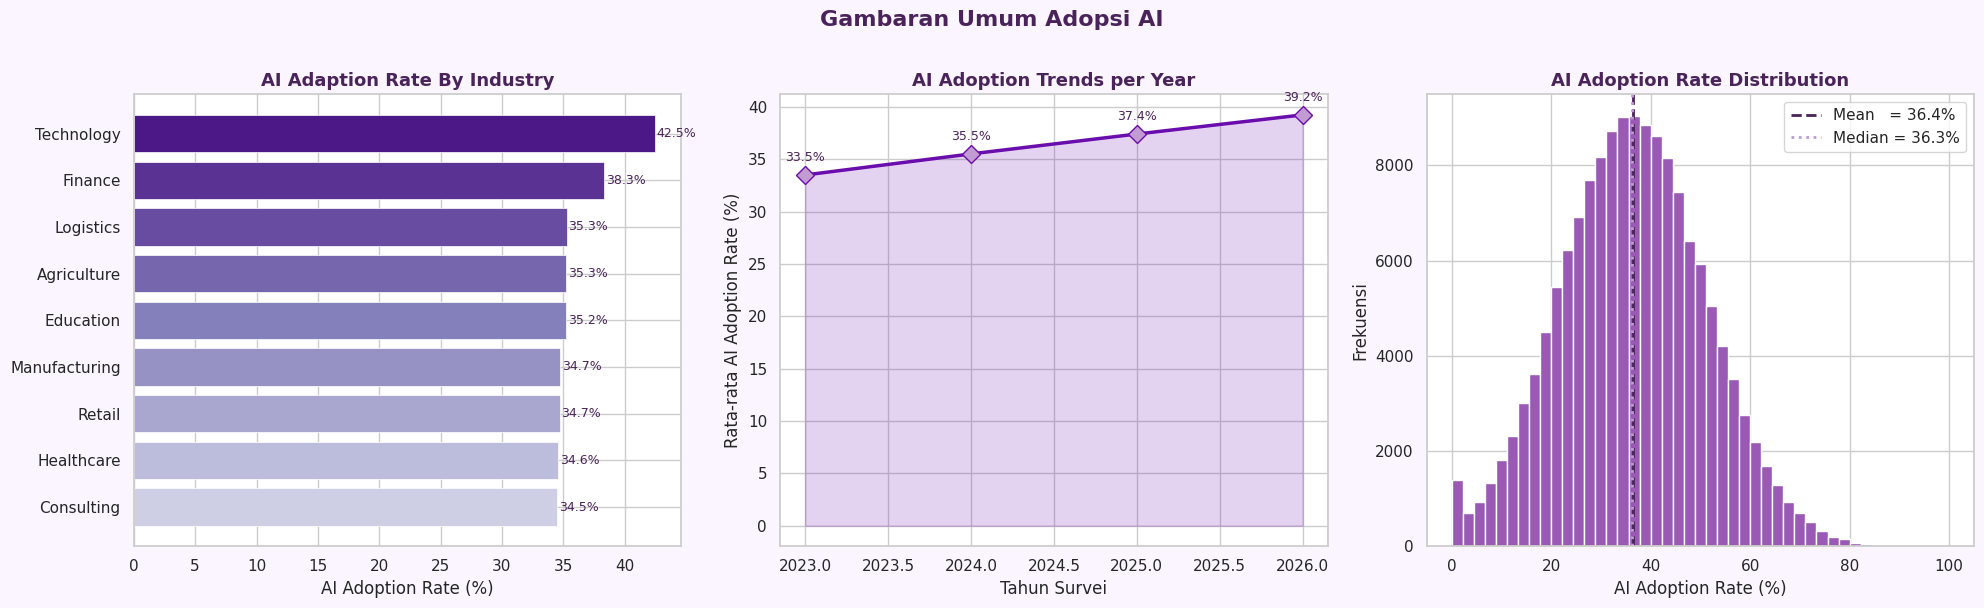

In [ ]:
# ===========================================================================================================================
# DISTRIBUSI TARGET | TREN TAHUNAN | RATA-RATA PER INDUSTRI
# ===========================================================================================================================
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.patch.set_facecolor('#faf5ff')

# -- Plot 1: Histogram distribusi target --
if 'industry' in df_clean.columns:
    ind_mean = df_clean.groupby('industry')[TARGET].mean().sort_values()
    bars     = axes[0].barh(ind_mean.index, ind_mean.values,
                            color=CLR_GRADIENT(len(ind_mean)),
                            edgecolor='white', lw=0.5)
    for i, val in enumerate(ind_mean.values):
        axes[0].text(val + 0.15, i, f'{val:.1f}%', va='center', fontsize=9, color=CLR_DARK)
    axes[0].set_title('AI Adaption Rate By Industry', fontsize=13, fontweight='bold', color=CLR_DARK)
    axes[0].set_xlabel('AI Adoption Rate (%)')

# -- Plot 2: Tren rata-rata per tahun --
if 'survey_year' in df_clean.columns:
    yearly_avg = df_clean.groupby('survey_year')[TARGET].mean()
    axes[1].plot(yearly_avg.index, yearly_avg.values,
                 marker='D', color=CLR_PRIMARY, lw=2.5, ms=9, markerfacecolor=CLR_SOFT)
    axes[1].fill_between(yearly_avg.index, yearly_avg.values, alpha=0.18, color=CLR_PRIMARY)
    axes[1].set_title('AI Adoption Trends per Year', fontsize=13, fontweight='bold', color=CLR_DARK)
    axes[1].set_xlabel('Tahun Survei')
    axes[1].set_ylabel('Rata-rata AI Adoption Rate (%)')
    for xv, yv in zip(yearly_avg.index, yearly_avg.values):
        axes[1].annotate(f'{yv:.1f}%', (xv, yv),
                         textcoords='offset points', xytext=(0, 10),
                         ha='center', fontsize=9, color=CLR_DARK)

# -- Plot 3: Histogram distribusi --
axes[2].hist(df_clean[TARGET], bins=45, color=CLR_SECONDARY, edgecolor='white', lw=0.4)
axes[2].axvline(df_clean[TARGET].mean(),   color=CLR_DARK,  ls='--', lw=2,
                label=f'Mean   = {df_clean[TARGET].mean():.1f}%')
axes[2].axvline(df_clean[TARGET].median(), color=CLR_SOFT,  ls=':',  lw=2,
                label=f'Median = {df_clean[TARGET].median():.1f}%')
axes[2].set_title('AI Adoption Rate Distribution', fontsize=13, fontweight='bold', color=CLR_DARK)
axes[2].set_xlabel('AI Adoption Rate (%)')
axes[2].set_ylabel('Frekuensi')
axes[2].legend()

plt.suptitle('Gambaran Umum Adopsi AI', fontsize=16, fontweight='bold', color=CLR_DARK, y=1.01)
plt.tight_layout()
plt.savefig('eda_overview.png', dpi=150, bbox_inches='tight')
plt.show()

Pada bagian AI Adoption Rate by Industry, sektor teknologi memiliki tingkat adopsi AI tertinggi dibandingkan industri lainnya, yaitu sekitar 42,5%. Hal ini menunjukkan bahwa industri teknologi menjadi pelopor dalam penerapan AI karena didukung oleh kesiapan infrastruktur, sumber daya manusia, serta kebutuhan inovasi yang tinggi. Sementara itu, sektor lain seperti finance, logistics, agriculture, education, manufacturing, retail, healthcare, dan consulting berada pada kisaran yang relatif berdekatan, yaitu 34% hingga 38%. Hal ini menunjukkan bahwa adopsi AI sudah mulai merata di berbagai sektor, meskipun tingkat kematangannya masih berbeda.

Pada bagian AI Adoption Trends per Year, terlihat adanya peningkatan yang konsisten dari tahun ke tahun. Pada tahun 2023, rata-rata adopsi AI berada di sekitar 33,5% dan terus meningkat hingga mencapai 39,2% pada tahun 2026. Tren ini menunjukkan bahwa adopsi AI berkembang secara stabil dan berkelanjutan, seiring dengan semakin banyaknya organisasi yang mulai mengintegrasikan AI ke dalam proses bisnis mereka.

Sementara itu, pada bagian AI Adoption Rate Distribution, histogram menunjukkan bahwa sebagian besar data terkonsentrasi pada rentang 30% hingga 40%, dengan nilai rata-rata sekitar 36,4% dan median 36,3%. Hal ini menunjukkan bahwa mayoritas organisasi berada pada tingkat adopsi menengah tidak terlalu rendah, tetapi juga belum mencapai tingkat adopsi yang sangat tinggi. Distribusi yang relatif simetris ini juga mengindikasikan bahwa sebaran data cukup merata tanpa adanya ketimpangan yang signifikan.

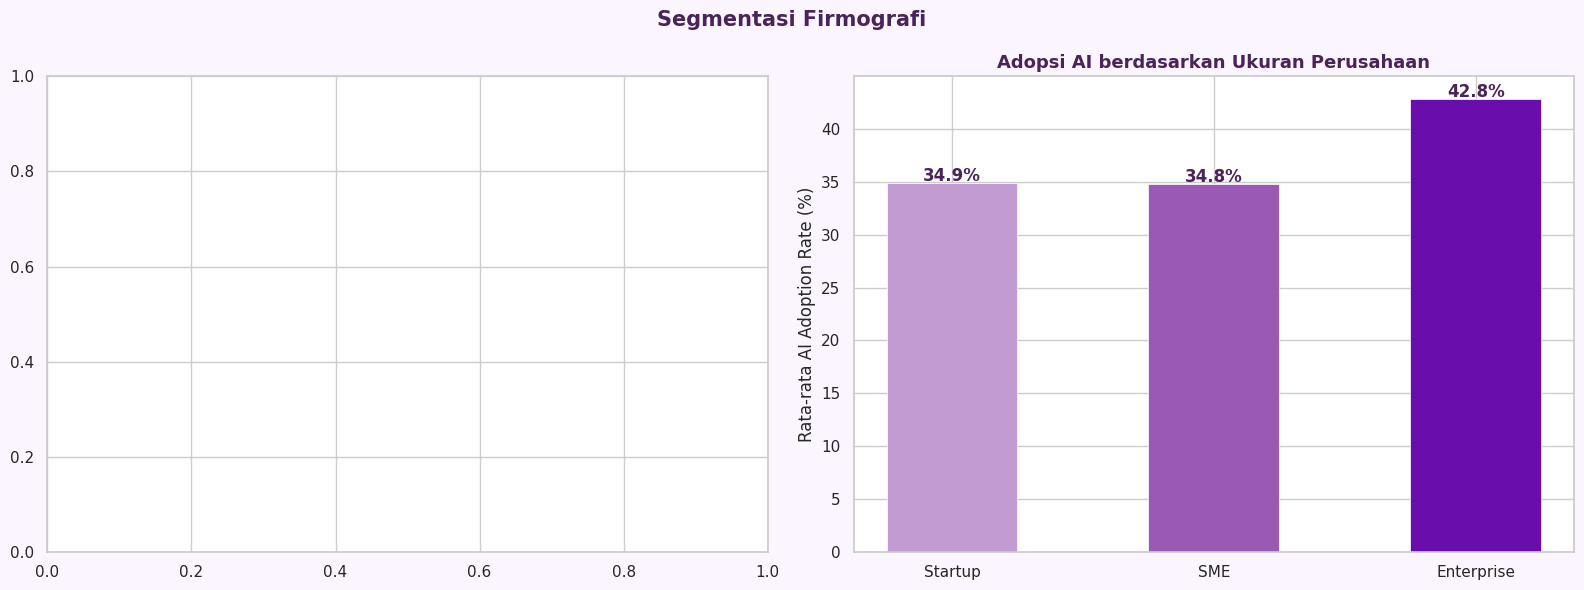

In [ ]:
# ===========================================================================================================================
# SEGMENTASI PERUSAHAAN | UKURAN & WILAYAH
# ===========================================================================================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor('#faf5ff')

# -- Plot 1: Adopsi AI per wilayah (dipindah ke kiri) --
if 'region' in df_clean.columns:
    region_avg = df_clean.groupby('region')[TARGET].mean().sort_values(ascending=False)
    axes[0].bar(region_avg.index, region_avg.values,
                color=CLR_GRADIENT(len(region_avg)),
                edgecolor='white', lw=0.5)
    axes[0].set_title('Adopsi AI per Wilayah', fontsize=13, fontweight='bold', color=CLR_DARK)
    axes[0].set_ylabel('Rata-rata AI Adoption Rate (%)')
    axes[0].tick_params(axis='x', rotation=28)
    for idx, val in enumerate(region_avg.values):
        axes[0].text(idx, val + 0.15, f'{val:.1f}%', ha='center', fontweight='bold', color=CLR_DARK)

# -- Plot 2: Adopsi AI per ukuran perusahaan --
if 'company_size' in df_clean.columns:
    size_order   = [s for s in ['Startup', 'SME', 'Enterprise'] if s in df_clean['company_size'].unique()]
    size_avg     = df_clean.groupby('company_size')[TARGET].mean().reindex(size_order)
    palette_size = [CLR_SOFT, CLR_SECONDARY, CLR_PRIMARY][:len(size_avg)]
    axes[1].bar(size_avg.index, size_avg.values,
                color=palette_size, edgecolor='white', lw=0.5, width=0.5)
    axes[1].set_title('Adopsi AI berdasarkan Ukuran Perusahaan', fontsize=13, fontweight='bold', color=CLR_DARK)
    axes[1].set_ylabel('Rata-rata AI Adoption Rate (%)')
    for idx, val in enumerate(size_avg.values):
        axes[1].text(idx, val + 0.15, f'{val:.1f}%', ha='center', fontweight='bold', color=CLR_DARK)

plt.suptitle('Segmentasi Firmografi', fontsize=15, fontweight='bold', color=CLR_DARK)
plt.tight_layout()
plt.savefig('eda_firmographic.png', dpi=150, bbox_inches='tight')
plt.show()

Grafik Segmentasi Firmografi menunjukkan bahwa tingkat adopsi AI berdasarkan ukuran perusahaan paling tinggi terdapat pada Enterprise dengan nilai sekitar 42,8%, yang menandakan bahwa perusahaan besar lebih siap dalam mengadopsi AI karena didukung oleh sumber daya, infrastruktur, dan kemampuan investasi yang lebih kuat. Sementara itu, Startup memiliki tingkat adopsi sebesar 34,9% dan SME sebesar 34,8%, yang menunjukkan bahwa keduanya berada pada tingkat yang hampir sama dan lebih rendah dibandingkan perusahaan besar, kemungkinan karena keterbatasan sumber daya dan prioritas bisnis yang masih berfokus pada operasional dasar. Secara keseluruhan, hasil ini menggambarkan bahwa semakin besar ukuran perusahaan, semakin tinggi tingkat adopsi AI yang dilakukan.

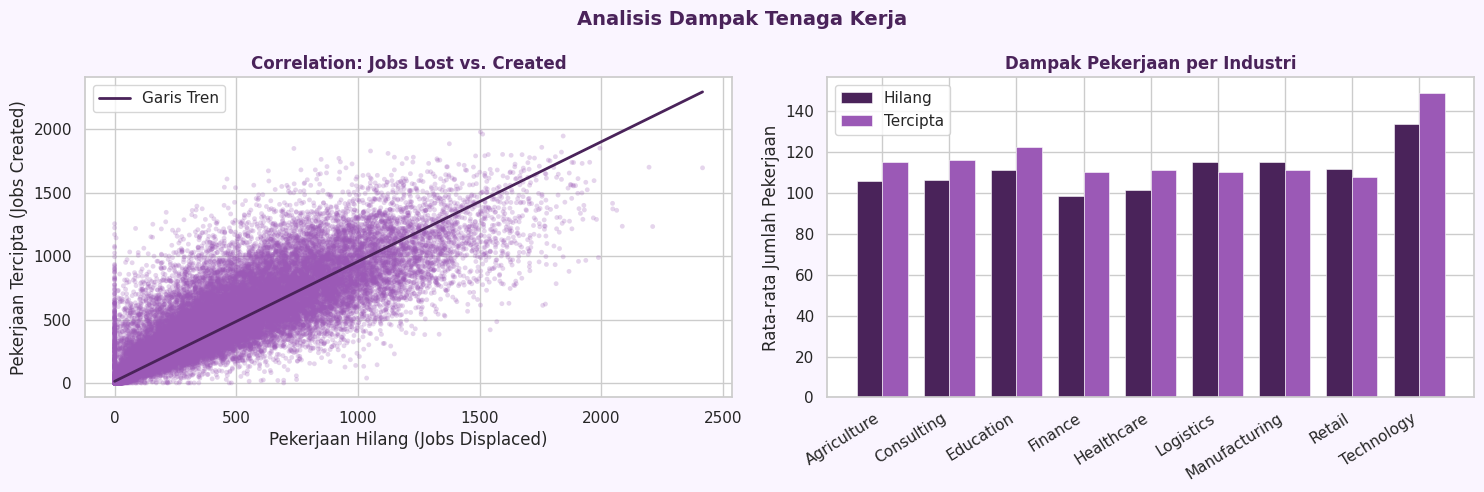

In [ ]:
# ===========================================================================================================================
# DAMPAK TENAGA KERJA | PEKERJAAN HILANG VS TERCIPTA
# ===========================================================================================================================
if 'jobs_displaced' in df_clean.columns and 'jobs_created' in df_clean.columns:
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    fig.patch.set_facecolor('#faf5ff')

    # -- Plot 1: Scatter jobs displaced vs created --
    axes[0].scatter(df_clean['jobs_displaced'], df_clean['jobs_created'],
                    alpha=0.25, s=12, color=CLR_SECONDARY, edgecolors='none')
    coef    = np.polyfit(df_clean['jobs_displaced'], df_clean['jobs_created'], 1)
    x_range = np.linspace(df_clean['jobs_displaced'].min(), df_clean['jobs_displaced'].max(), 120)
    axes[0].plot(x_range, np.poly1d(coef)(x_range), color=CLR_DARK, lw=2, label='Garis Tren')
    axes[0].set_xlabel('Pekerjaan Hilang (Jobs Displaced)')
    axes[0].set_ylabel('Pekerjaan Tercipta (Jobs Created)')
    axes[0].set_title('Correlation: Jobs Lost vs. Created', fontsize=12, fontweight='bold', color=CLR_DARK)
    axes[0].legend()

    # -- Plot 2: Grouped bar per industri --
    if 'industry' in df_clean.columns:
        workforce_by_industry = df_clean.groupby('industry')[['jobs_displaced', 'jobs_created']].mean()
        x_pos, bar_w          = np.arange(len(workforce_by_industry)), 0.38
        axes[1].bar(x_pos - bar_w/2, workforce_by_industry['jobs_displaced'], bar_w,
                    label='Hilang',   color=CLR_DARK,      edgecolor='white', lw=0.4)
        axes[1].bar(x_pos + bar_w/2, workforce_by_industry['jobs_created'],   bar_w,
                    label='Tercipta', color=CLR_SECONDARY,  edgecolor='white', lw=0.4)
        axes[1].set_xticks(x_pos)
        axes[1].set_xticklabels(workforce_by_industry.index, rotation=32, ha='right')
        axes[1].set_title('Dampak Pekerjaan per Industri', fontsize=12, fontweight='bold', color=CLR_DARK)
        axes[1].set_ylabel('Rata-rata Jumlah Pekerjaan')
        axes[1].legend()

    plt.suptitle('Analisis Dampak Tenaga Kerja', fontsize=14, fontweight='bold', color=CLR_DARK)
    plt.tight_layout()
    plt.savefig('eda_workforce.png', dpi=150, bbox_inches='tight')
    plt.show()

Terdapat korelasi positif yang kuat antara jumlah pekerjaan yang hilang dan pekerjaan yang tercipta dimana, semakin banyak pekerjaan yang tergantikan, semakin banyak pula peluang kerja baru yang muncul, meskipun tidak selalu sebanding sempurna. Selain itu, dari sisi industri, hampir semua sektor mengalami dinamika serupa, di mana jumlah pekerjaan yang tercipta umumnya sedikit lebih tinggi dibanding yang hilang, terutama pada sektor teknologi yang memiliki pertumbuhan paling signifikan. Hal ini mengindikasikan bahwa transformasi tenaga kerja cenderung mengarah pada pergeseran jenis pekerjaan, bukan sekadar pengurangan total lapangan kerja.

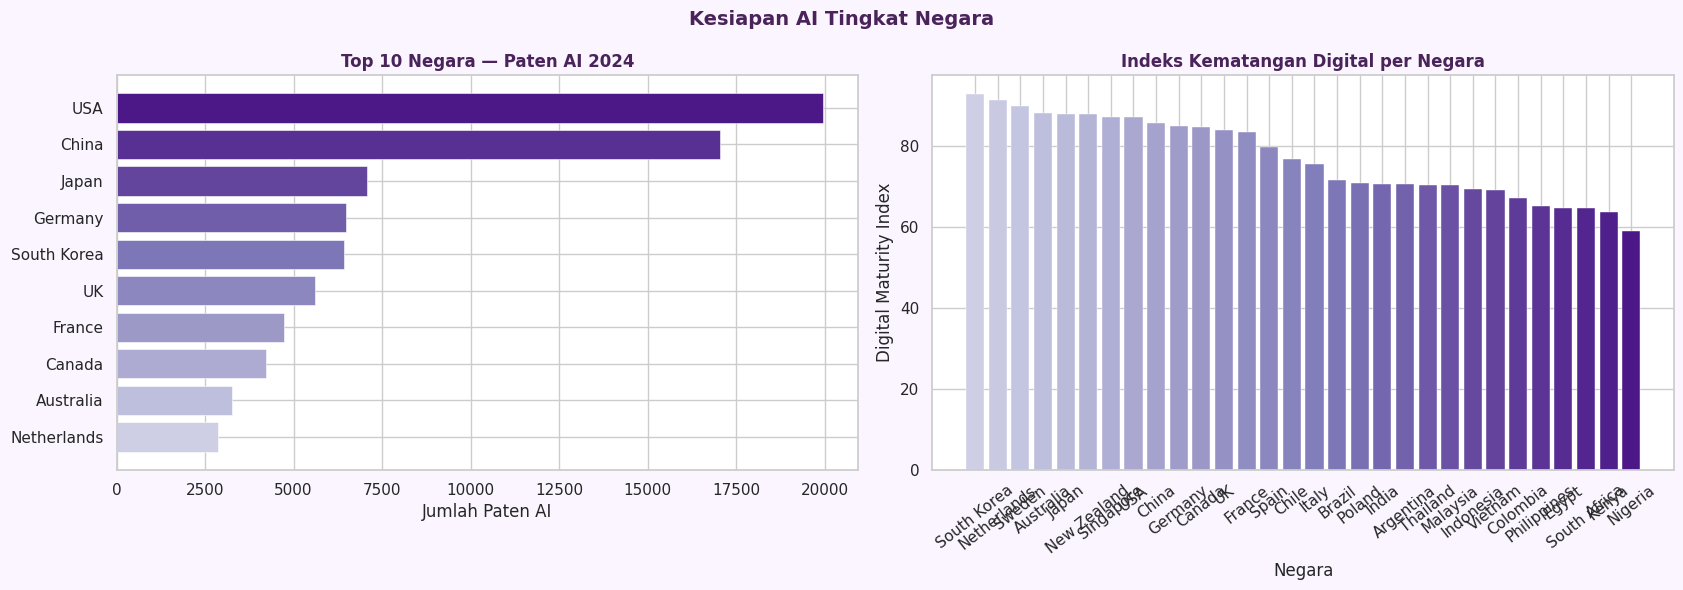

In [ ]:
# ===========================================================================================================================
# KESIAPAN NEGARA | DIGITAL MATURITY & PATEN AI
# ===========================================================================================================================
if df_country is not None:
    fig, axes = plt.subplots(1, 2, figsize=(17, 6))
    fig.patch.set_facecolor('#faf5ff')

    # -- Plot 1: Top 10 paten AI (dipindah ke kiri) --
    top10_patent = df_country.nlargest(10, 'ai_patent_filings_2024').sort_values('ai_patent_filings_2024')
    axes[0].barh(top10_patent['country'], top10_patent['ai_patent_filings_2024'],
                 color=CLR_GRADIENT(10), edgecolor='white', lw=0.4)
    axes[0].set_title('Top 10 Negara — Paten AI 2024', fontsize=12, fontweight='bold', color=CLR_DARK)
    axes[0].set_xlabel('Jumlah Paten AI')

    # -- Plot 2: Digital maturity index --
    df_sorted_dm = df_country.sort_values('digital_maturity_index', ascending=False)
    axes[1].bar(df_sorted_dm['country'], df_sorted_dm['digital_maturity_index'],
                color=CLR_GRADIENT(len(df_sorted_dm)), edgecolor='white', lw=0.3)
    axes[1].set_title('Indeks Kematangan Digital per Negara', fontsize=12, fontweight='bold', color=CLR_DARK)
    axes[1].set_xlabel('Negara')
    axes[1].set_ylabel('Digital Maturity Index')
    axes[1].tick_params(axis='x', rotation=38)

    plt.suptitle('Kesiapan AI Tingkat Negara', fontsize=14, fontweight='bold', color=CLR_DARK)
    plt.tight_layout()
    plt.savefig('eda_countries.png', dpi=150, bbox_inches='tight')
    plt.show()

Pada grafik kiri, terlihat bahwa Amerika Serikat dan China mendominasi jumlah paten AI, jauh di atas negara lain. Ini menandakan kedua negara menjadi pusat inovasi dan pengembangan teknologi AI global. Negara seperti Jepang, Jerman, dan Korea Selatan berada di posisi menengah, sementara negara lain memiliki jumlah paten yang lebih sedikit.

Sementara itu, grafik kanan menunjukkan indeks kematangan digital, di mana negara seperti Korea Selatan, Belanda, dan negara-negara Eropa memiliki skor tinggi. Artinya, mereka memiliki infrastruktur digital, teknologi, dan kesiapan penggunaan AI yang sangat baik, meskipun tidak selalu memiliki jumlah paten terbanyak.

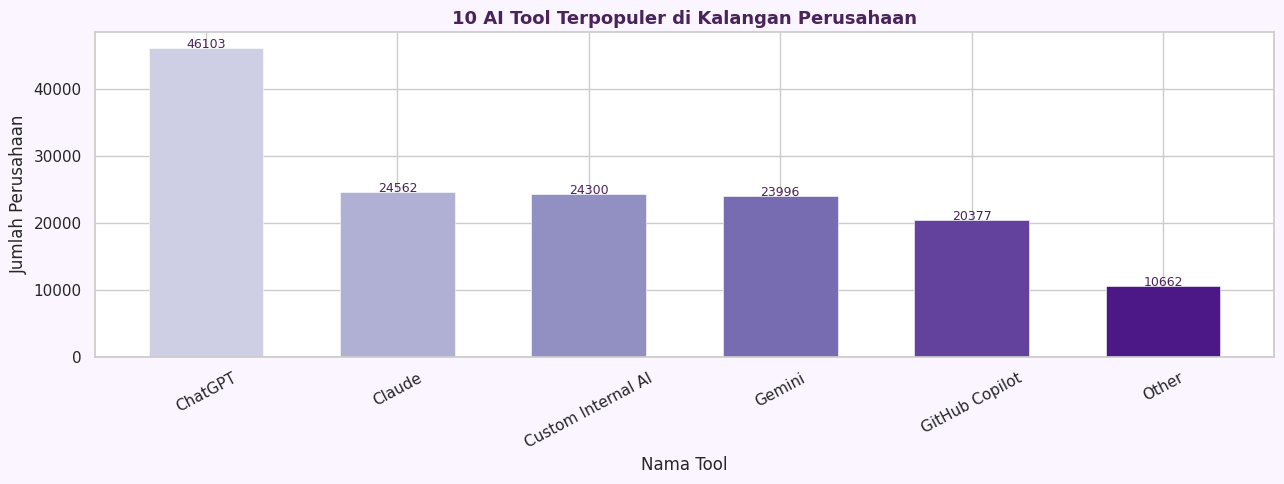

In [ ]:
# ===========================================================================================================================
# TOOLS AI TERPOPULER | TOP 10 ALAT YANG DIGUNAKAN
# ===========================================================================================================================
if 'ai_primary_tool' in df_clean.columns:
    fig, ax = plt.subplots(figsize=(13, 5))
    fig.patch.set_facecolor('#faf5ff')

    top_tools = df_clean['ai_primary_tool'].value_counts().head(10)
    ax.bar(top_tools.index, top_tools.values,
           color=CLR_GRADIENT(len(top_tools)),
           edgecolor='white', lw=0.4, width=0.6)
    ax.set_title('10 AI Tool Terpopuler di Kalangan Perusahaan', fontsize=13, fontweight='bold', color=CLR_DARK)
    ax.set_xlabel('Nama Tool')
    ax.set_ylabel('Jumlah Perusahaan')
    ax.tick_params(axis='x', rotation=28)
    for i, val in enumerate(top_tools.values):
        ax.text(i, val + 3, str(val), ha='center', fontsize=9, color=CLR_DARK)

    plt.tight_layout()
    plt.savefig('eda_tools.png', dpi=150, bbox_inches='tight')
    plt.show()

Grafik tersebut menunjukkan bahwa ChatGPT merupakan AI tool paling populer di kalangan perusahaan dengan jumlah penggunaan yang jauh lebih tinggi dibandingkan yang lain (sekitar 46 ribu), sementara tools seperti Claude, Custom Internal AI, dan Gemini berada di posisi menengah dengan penggunaan yang relatif seimbang (sekitar 23–24 ribu), diikuti oleh GitHub Copilot yang sedikit lebih rendah (sekitar 20 ribu) karena lebih fokus pada kebutuhan coding, dan kategori Other menjadi yang paling sedikit digunakan. Secara keseluruhan, ChatGPT mendominasi adopsi AI secara luas, sedangkan tools lainnya digunakan sebagai pelengkap atau untuk kebutuhan yang lebih spesifik di perusahaan.

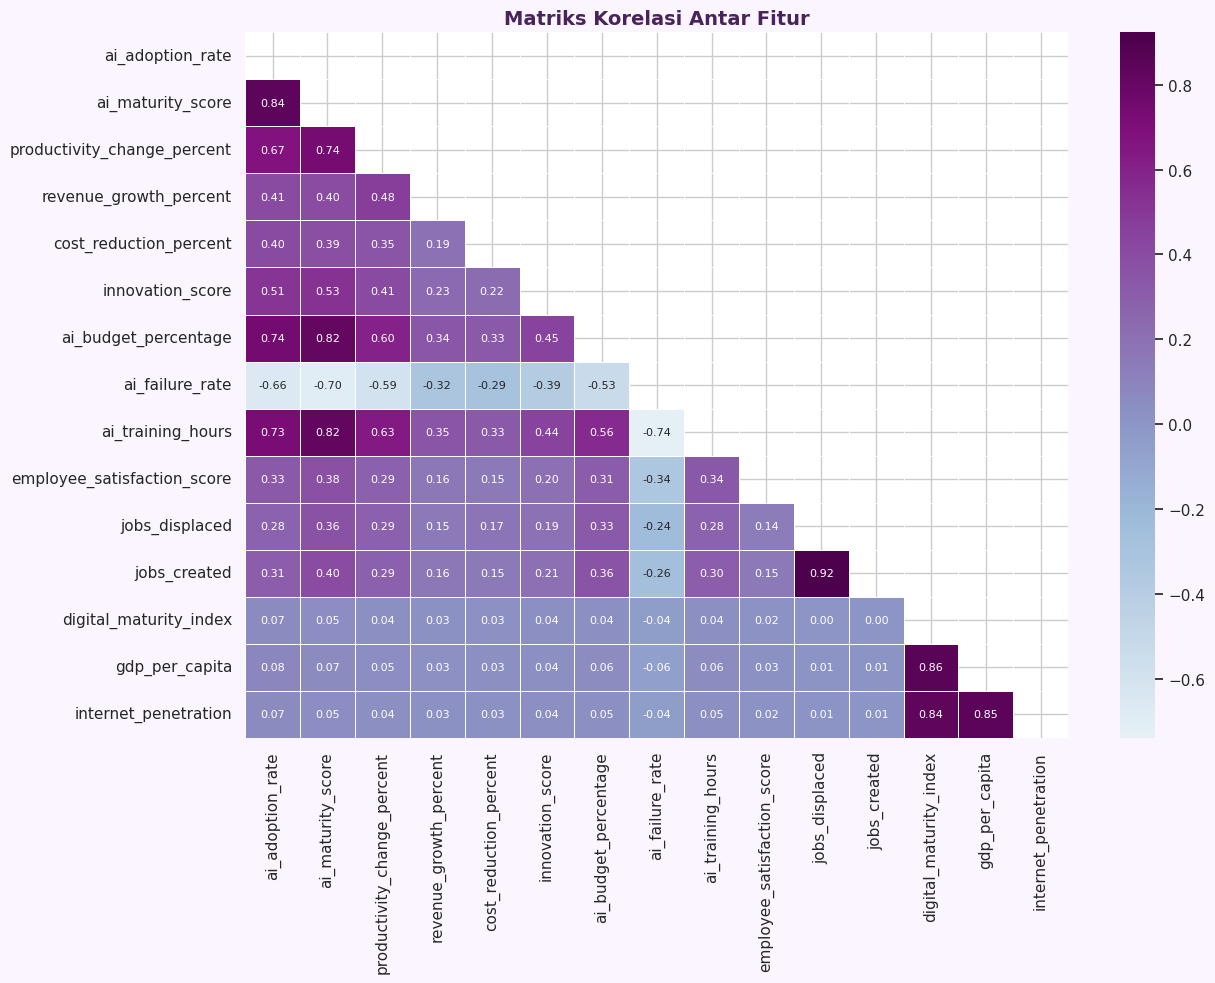

In [ ]:
# ===========================================================================================================================
# MATRIKS KORELASI | HUBUNGAN ANTAR FITUR UTAMA
# ===========================================================================================================================
feature_pool = [
    'ai_adoption_rate', 'ai_maturity_score', 'productivity_change_percent',
    'revenue_growth_percent', 'cost_reduction_percent', 'innovation_score',
    'ai_budget_percentage', 'ai_failure_rate', 'ai_training_hours',
    'employee_satisfaction_score', 'jobs_displaced', 'jobs_created',
    'digital_maturity_index', 'gdp_per_capita', 'internet_penetration'
]
selected_features = [col for col in feature_pool if col in df_clean.columns][:15]

if len(selected_features) >= 4:
    fig, ax = plt.subplots(figsize=(13, 10))
    fig.patch.set_facecolor('#faf5ff')

    corr_matrix  = df_clean[selected_features].corr()
    upper_mask   = np.triu(np.ones_like(corr_matrix, dtype=bool))
    sns.heatmap(corr_matrix, mask=upper_mask, annot=True, fmt='.2f',
                cmap=HEATMAP_CMAP, center=0, linewidths=0.6,
                ax=ax, annot_kws={'size': 8}, linecolor='white')
    ax.set_title('Matriks Korelasi Antar Fitur', fontsize=14, fontweight='bold', color=CLR_DARK)
    plt.tight_layout()
    plt.savefig('eda_correlation.png', dpi=150, bbox_inches='tight')
    plt.show()

Matriks korelasi tersebut menunjukkan bahwa adopsi AI memiliki hubungan positif kuat dengan berbagai indikator kinerja, seperti AI maturity score, productivity change, dan AI budget, yang berarti semakin tinggi penggunaan AI, semakin meningkat produktivitas dan investasi perusahaan. Selain itu, jumlah pekerjaan yang hilang dan tercipta memiliki korelasi sangat tinggi (0,92), menandakan bahwa kehilangan pekerjaan akibat AI sering diikuti penciptaan pekerjaan baru. Di sisi lain, AI failure rate berkorelasi negatif dengan banyak variabel (misalnya dengan training hours dan maturity), yang menunjukkan bahwa semakin matang dan terlatih penggunaan AI, semakin kecil tingkat kegagalannya. Sementara itu, faktor eksternal seperti GDP per capita, digital maturity, dan internet penetration saling berkorelasi kuat, tetapi memiliki hubungan yang relatif kecil dengan variabel AI internal, sehingga dapat disimpulkan bahwa keberhasilan implementasi AI lebih dipengaruhi oleh strategi dan kesiapan internal dibanding faktor eksternal semata.

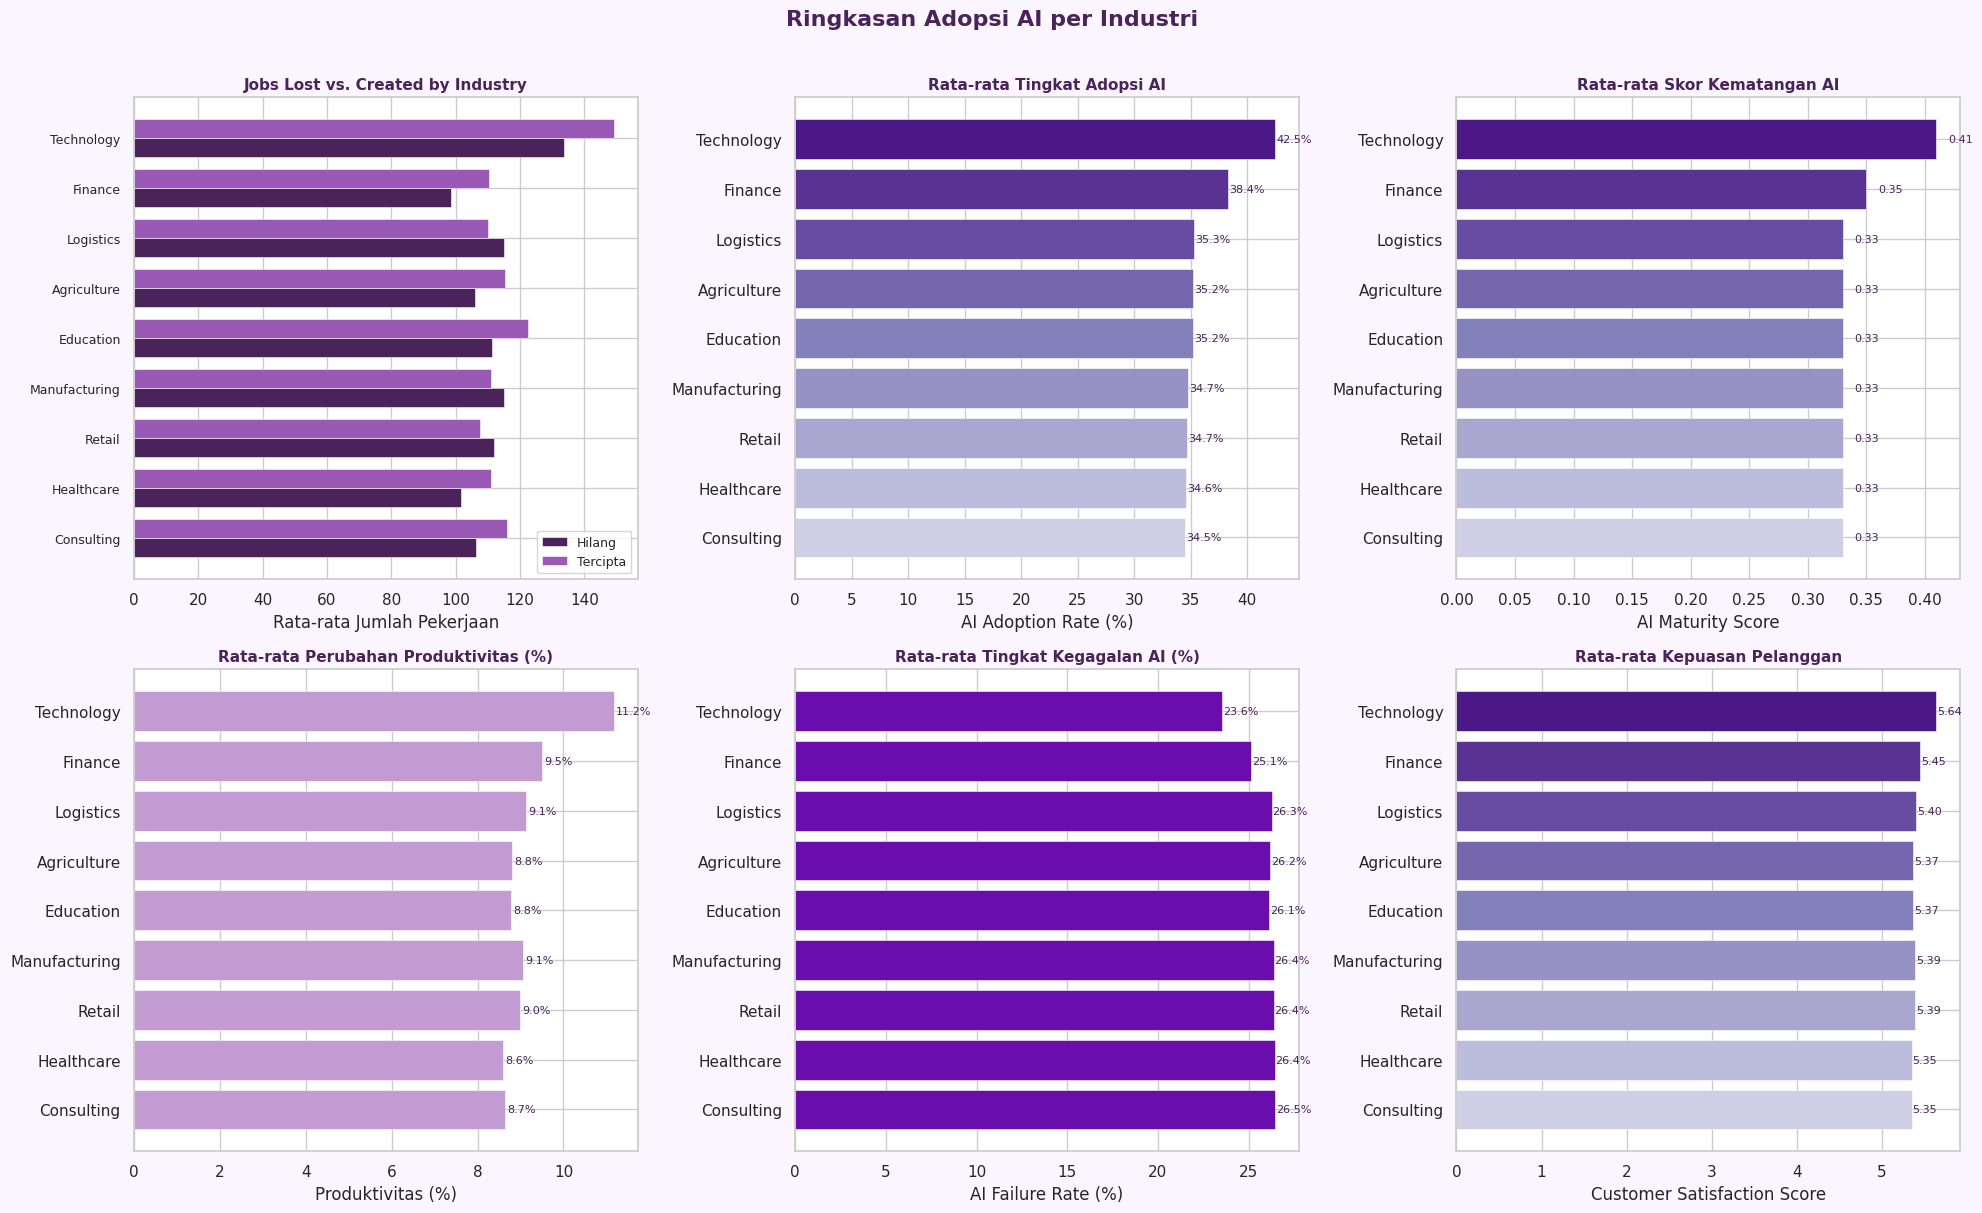


Detail Tabel Industry Summary:


,industry,avg_ai_adoption_rate,avg_productivity_change_percent,avg_ai_maturity_score,avg_ai_failure_rate,avg_jobs_displaced,avg_jobs_created,avg_customer_satisfaction
8,Technology,42.47,11.17,0.41,23.56,133.74,149.08,5.64
3,Finance,38.35,9.50,0.35,25.12,98.44,110.42,5.45
5,Logistics,35.26,9.13,0.33,26.27,114.99,110.09,5.40
0,Agriculture,35.25,8.80,0.33,26.19,106.09,115.28,5.37
2,Education,35.23,8.79,0.33,26.13,111.25,122.58,5.37
6,Manufacturing,34.73,9.05,0.33,26.38,115.06,111.10,5.39
7,Retail,34.70,8.99,0.33,26.38,111.87,107.65,5.39
4,Healthcare,34.57,8.60,0.33,26.44,101.51,110.98,5.35
1,Consulting,34.52,8.65,0.33,26.46,106.33,116.06,5.35


In [ ]:
# ===========================================================================================================================
# INDUSTRY SUMMARY DEEP DIVE
# ===========================================================================================================================
if df_industry is not None:

    df_ind = df_industry.copy().sort_values('avg_ai_adoption_rate', ascending=True)
    n_ind  = len(df_ind)
    x_pos  = np.arange(n_ind)
    bar_w  = 0.38

    fig, axes = plt.subplots(2, 3, figsize=(20, 12))
    fig.patch.set_facecolor('#faf5ff')

    # ===========================================================================================================================
    # ADOPSI, KEMATANGAN, & PRODUKTIVITAS
    # ===========================================================================================================================

    # -- [0,0] Avg Jobs Displaced vs Created per Industri --
    axes[0, 0].barh(x_pos - bar_w/2, df_ind['avg_jobs_displaced'], bar_w,
                    label='Hilang',   color=CLR_DARK,      edgecolor='white', lw=0.4)
    axes[0, 0].barh(x_pos + bar_w/2, df_ind['avg_jobs_created'],   bar_w,
                    label='Tercipta', color=CLR_SECONDARY,  edgecolor='white', lw=0.4)
    axes[0, 0].set_yticks(x_pos)
    axes[0, 0].set_yticklabels(df_ind['industry'], fontsize=9)
    axes[0, 0].set_title('Jobs Lost vs. Created by Industry', fontsize=11, fontweight='bold', color=CLR_DARK)
    axes[0, 0].set_xlabel('Rata-rata Jumlah Pekerjaan')
    axes[0, 0].legend(fontsize=9)

    # -- [0,1] Avg AI Adoption Rate --
    axes[0, 1].barh(df_ind['industry'], df_ind['avg_ai_adoption_rate'],
                    color=CLR_GRADIENT(n_ind), edgecolor='white', lw=0.4)
    axes[0, 1].set_title('Rata-rata Tingkat Adopsi AI', fontsize=11, fontweight='bold', color=CLR_DARK)
    axes[0, 1].set_xlabel('AI Adoption Rate (%)')
    for i, val in enumerate(df_ind['avg_ai_adoption_rate']):
        axes[0, 1].text(val + 0.1, i, f'{val:.1f}%', va='center', fontsize=8, color=CLR_DARK)

    # -- [0,2] Avg AI Maturity Score --
    axes[0, 2].barh(df_ind['industry'], df_ind['avg_ai_maturity_score'],
                    color=CLR_GRADIENT(n_ind), edgecolor='white', lw=0.4)
    axes[0, 2].set_title('Rata-rata Skor Kematangan AI', fontsize=11, fontweight='bold', color=CLR_DARK)
    axes[0, 2].set_xlabel('AI Maturity Score')
    for i, val in enumerate(df_ind['avg_ai_maturity_score']):
        axes[0, 2].text(val + 0.01, i, f'{val:.2f}', va='center', fontsize=8, color=CLR_DARK)

    # ===========================================================================================================================
    # DAMPAK BISNIS & KEGAGALAN
    # ===========================================================================================================================

    # -- [1,0] Avg Productivity Change --
    axes[1, 0].barh(df_ind['industry'], df_ind['avg_productivity_change_percent'],
                    color=CLR_SOFT, edgecolor='white', lw=0.4)
    axes[1, 0].set_title('Rata-rata Perubahan Produktivitas (%)', fontsize=11, fontweight='bold', color=CLR_DARK)
    axes[1, 0].set_xlabel('Produktivitas (%)')
    for i, val in enumerate(df_ind['avg_productivity_change_percent']):
        axes[1, 0].text(val + 0.05, i, f'{val:.1f}%', va='center', fontsize=8, color=CLR_DARK)

    # -- [1,1] Avg AI Failure Rate --
    axes[1, 1].barh(df_ind['industry'], df_ind['avg_ai_failure_rate'],
                    color=CLR_PRIMARY, edgecolor='white', lw=0.4)
    axes[1, 1].set_title('Rata-rata Tingkat Kegagalan AI (%)', fontsize=11, fontweight='bold', color=CLR_DARK)
    axes[1, 1].set_xlabel('AI Failure Rate (%)')
    for i, val in enumerate(df_ind['avg_ai_failure_rate']):
        axes[1, 1].text(val + 0.05, i, f'{val:.1f}%', va='center', fontsize=8, color=CLR_DARK)

    # -- [1,2] Avg Customer Satisfaction --
    axes[1, 2].barh(df_ind['industry'], df_ind['avg_customer_satisfaction'],
                    color=CLR_GRADIENT(n_ind), edgecolor='white', lw=0.4)
    axes[1, 2].set_title('Rata-rata Kepuasan Pelanggan', fontsize=11, fontweight='bold', color=CLR_DARK)
    axes[1, 2].set_xlabel('Customer Satisfaction Score')
    for i, val in enumerate(df_ind['avg_customer_satisfaction']):
        axes[1, 2].text(val + 0.01, i, f'{val:.2f}', va='center', fontsize=8, color=CLR_DARK)

    # ===========================================================================================================================
    # FINALISASI
    # ===========================================================================================================================
    plt.suptitle('Ringkasan Adopsi AI per Industri', fontsize=16, fontweight='bold', color=CLR_DARK, y=1.01)
    plt.tight_layout()
    plt.savefig('industry_summary.png', dpi=150, bbox_inches='tight')
    plt.show()

    print('\nDetail Tabel Industry Summary:')
    display(df_industry.sort_values('avg_ai_adoption_rate', ascending=False))

else:
    print('⚠️ File industry summary tidak ditemukan — visualisasi dilewati.')

Secara keseluruhan, visualisasi ini menunjukkan bahwa industri teknologi memimpin dalam adopsi AI, kematangan AI, serta peningkatan produktivitas dan kepuasan pelanggan, dengan tingkat adopsi tertinggi (~42,5%) dan produktivitas terbesar (~11,2%). Hampir semua industri mengalami pola yang mirip, yaitu jumlah pekerjaan yang tercipta sedikit lebih tinggi dibanding yang hilang, menandakan adanya pergeseran pekerjaan akibat AI, bukan pengurangan total. Di sisi lain, tingkat kegagalan AI relatif mirip di semua sektor (sekitar 23–26%), menunjukkan bahwa tantangan implementasi masih umum terjadi. Industri seperti finance dan logistics juga menunjukkan performa yang cukup tinggi, sementara sektor lain seperti agriculture, education, dan consulting tetap mendapatkan manfaat AI meskipun tidak sekuat teknologi.

In [ ]:
# ===========================================================================================================================
# TOP & BOTTOM INSIGHT ANALYSIS
# ===========================================================================================================================

print("\n📊 TOP 5 INDUSTRI DENGAN AI ADOPTION TERTINGGI")
display(df_industry.sort_values('avg_ai_adoption_rate', ascending=False).head(5))

print("\n📉 BOTTOM 5 INDUSTRI DENGAN AI ADOPTION TERENDAH")
display(df_industry.sort_values('avg_ai_adoption_rate', ascending=True).head(5))


📊 TOP 5 INDUSTRI DENGAN AI ADOPTION TERTINGGI


,industry,avg_ai_adoption_rate,avg_productivity_change_percent,avg_ai_maturity_score,avg_ai_failure_rate,avg_jobs_displaced,avg_jobs_created,avg_customer_satisfaction
8,Technology,42.47,11.17,0.41,23.56,133.74,149.08,5.64
3,Finance,38.35,9.50,0.35,25.12,98.44,110.42,5.45
5,Logistics,35.26,9.13,0.33,26.27,114.99,110.09,5.40
0,Agriculture,35.25,8.80,0.33,26.19,106.09,115.28,5.37
2,Education,35.23,8.79,0.33,26.13,111.25,122.58,5.37



📉 BOTTOM 5 INDUSTRI DENGAN AI ADOPTION TERENDAH


,industry,avg_ai_adoption_rate,avg_productivity_change_percent,avg_ai_maturity_score,avg_ai_failure_rate,avg_jobs_displaced,avg_jobs_created,avg_customer_satisfaction
1,Consulting,34.52,8.65,0.33,26.46,106.33,116.06,5.35
4,Healthcare,34.57,8.60,0.33,26.44,101.51,110.98,5.35
7,Retail,34.70,8.99,0.33,26.38,111.87,107.65,5.39
6,Manufacturing,34.73,9.05,0.33,26.38,115.06,111.10,5.39
2,Education,35.23,8.79,0.33,26.13,111.25,122.58,5.37


In [ ]:
# ===========================================================================================================================
# OUTLIER DETECTION (IQR METHOD)
# ===========================================================================================================================

def detect_outliers(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return df[(df[col] < lower) | (df[col] > upper)]

outlier_col = 'ai_adoption_rate'

outliers = detect_outliers(df_clean, outlier_col)

print(f"Jumlah outlier pada {outlier_col}: {len(outliers)}")
display(outliers.head())

Jumlah outlier pada ai_adoption_rate: 504


,survey_year,quarter,country,region_x,industry,company_size,num_employees,annual_revenue_usd_millions,company_founding_year,company_age,...,cost_reduction_percent,innovation_score,customer_satisfaction,region_y,gdp_per_capita,internet_penetration,digital_maturity_index,country_ai_policy,ai_patent_filings_2024,ai_researchers_per_million
185,2025,Q1,Thailand,Asia,Agriculture,SME,382,245.48,2010,15,...,14.16,61,5.16,Asia,18377.10,81.59,70.46,Moderate,1254,150.82
446,2024,Q4,Singapore,Asia,Healthcare,Enterprise,1876,2346.61,2019,5,...,6.60,70,6.45,Asia,72930.10,93.78,87.28,Moderate,2218,501.20
448,2025,Q2,Singapore,Asia,Healthcare,Enterprise,1876,2346.61,2019,6,...,4.68,66,6.20,Asia,72930.10,93.78,87.28,Moderate,2218,501.20
537,2025,Q2,Nigeria,Africa,Technology,SME,587,470.58,1990,35,...,8.14,72,7.29,Africa,6133.11,56.40,59.10,Lenient,240,55.23
599,2025,Q2,Australia,Oceania,Education,Startup,57,40.54,2022,3,...,5.95,69,7.15,Oceania,64279.23,94.50,88.05,Moderate,3270,390.71


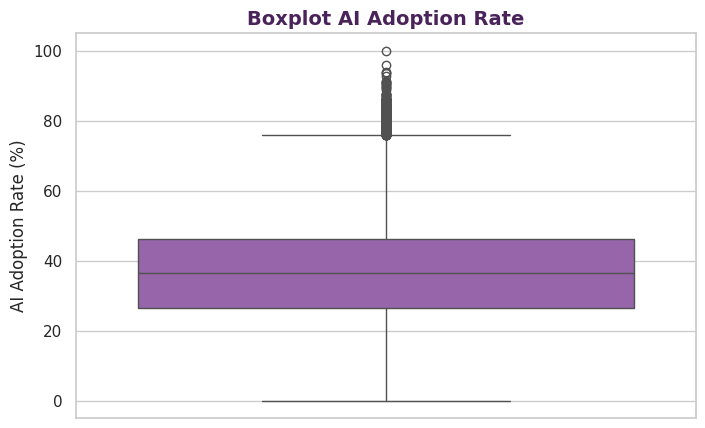

In [ ]:
# ===========================================================================================================================
# BOXPLOT AI ADOPTION RATE
# ===========================================================================================================================

plt.figure(figsize=(8,5))

sns.boxplot(y=df_clean['ai_adoption_rate'], color=CLR_SECONDARY)

plt.title('Boxplot AI Adoption Rate', color=CLR_DARK, fontsize=14, fontweight='bold')
plt.ylabel('AI Adoption Rate (%)')

plt.show()

Boxplot tersebut menunjukkan bahwa tingkat adopsi AI sebagian besar berada pada rentang sekitar 25% hingga 45%, dengan median (nilai tengah) di kisaran pertengahan 30%. Ini berarti sebagian besar data terkonsentrasi di area tersebut. Namun, terdapat banyak outlier di bagian atas (sekitar 75% hingga mendekati 100%), yang menunjukkan ada sejumlah kasus dengan tingkat adopsi AI yang jauh lebih tinggi dibandingkan mayoritas. Selain itu, whisker bawah yang mendekati 0% menandakan adanya nilai minimum yang sangat rendah, sehingga distribusi data cenderung tidak simetris dan sedikit condong ke kanan (positively skewed).

In [ ]:
# ===========================================================================================================================
# HEATMAP: REGION vs INDUSTRY (MEAN AI ADOPTION)
# ===========================================================================================================================

if 'region' in df_clean.columns and 'industry' in df_clean.columns:

    pivot_table = df_clean.pivot_table(
        values='ai_adoption_rate',
        index='region',
        columns='industry',
        aggfunc='mean'
    )

    plt.figure(figsize=(14,7))

    sns.heatmap(pivot_table,
                cmap=HEATMAP_CMAP,
                linewidths=0.5)

    plt.title('Heatmap Region vs Industry (AI Adoption Rate)',
              color=CLR_DARK, fontsize=14, fontweight='bold')

    plt.show()

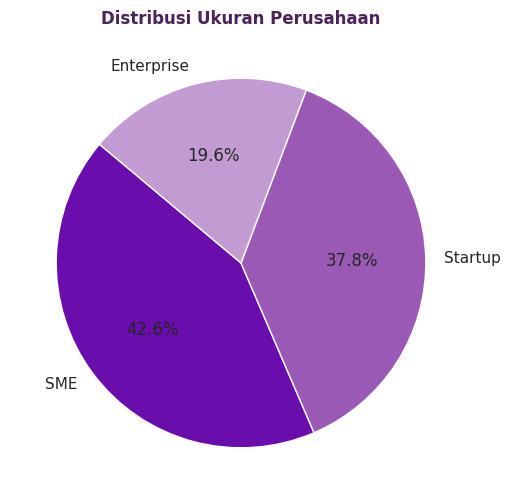

In [ ]:
# ===========================================================================================================================
# PIE CHART COMPANY SIZE DISTRIBUTION
# ===========================================================================================================================

if 'company_size' in df_clean.columns:

    size_counts = df_clean['company_size'].value_counts()

    plt.figure(figsize=(6,6))

    plt.pie(size_counts,
            labels=size_counts.index,
            autopct='%1.1f%%',
            colors=[CLR_PRIMARY, CLR_SECONDARY, CLR_SOFT],
            startangle=140)

    plt.title('Distribusi Ukuran Perusahaan',
              color=CLR_DARK, fontweight='bold')

    plt.show()

Berdasarkan diagram pie tersebut, terlihat bahwa kategori **SME** memiliki proporsi terbesar yaitu sekitar 42,6%, diikuti oleh **Startup** sebesar 37,8%, dan kategori lainnya sekitar 19,6%. Hal ini menunjukkan bahwa adopsi atau kontribusi terbesar berasal dari sektor SME, sementara Startup juga memiliki peran yang cukup signifikan meskipun sedikit lebih rendah. Sementara itu, kategori terakhir memiliki porsi paling kecil, sehingga kontribusinya relatif lebih terbatas dibandingkan dua kategori lainnya.

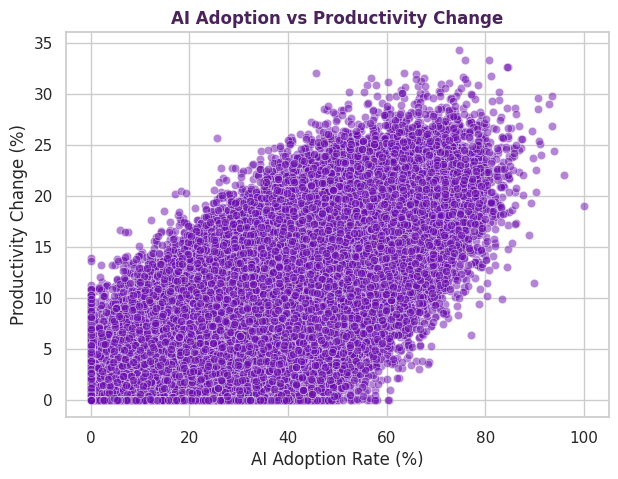

In [ ]:
# ===========================================================================================================================
# SCATTER: AI ADOPTION vs PRODUCTIVITY
# ===========================================================================================================================

if 'productivity_change_percent' in df_clean.columns:

    plt.figure(figsize=(7,5))

    sns.scatterplot(
        data=df_clean,
        x='ai_adoption_rate',
        y='productivity_change_percent',
        color=CLR_PRIMARY,
        alpha=0.5
    )

    plt.title('AI Adoption vs Productivity Change',
              color=CLR_DARK, fontweight='bold')

    plt.xlabel('AI Adoption Rate (%)')
    plt.ylabel('Productivity Change (%)')

    plt.show()

Berdasarkan scatter plot tersebut, terlihat adanya hubungan positif antara tingkat adopsi AI dan perubahan produktivitas. Semakin tinggi persentase adopsi AI, cenderung semakin besar peningkatan produktivitas yang dicapai. Titik-titik data membentuk pola naik dari kiri bawah ke kanan atas, yang menunjukkan korelasi yang cukup kuat. Namun, penyebaran titik juga cukup lebar, artinya pada tingkat adopsi yang sama, peningkatan produktivitas bisa bervariasi. Selain itu, terdapat beberapa titik dengan produktivitas rendah meskipun adopsi AI tinggi, yang menandakan bahwa faktor lain juga mempengaruhi produktivitas selain penggunaan AI.

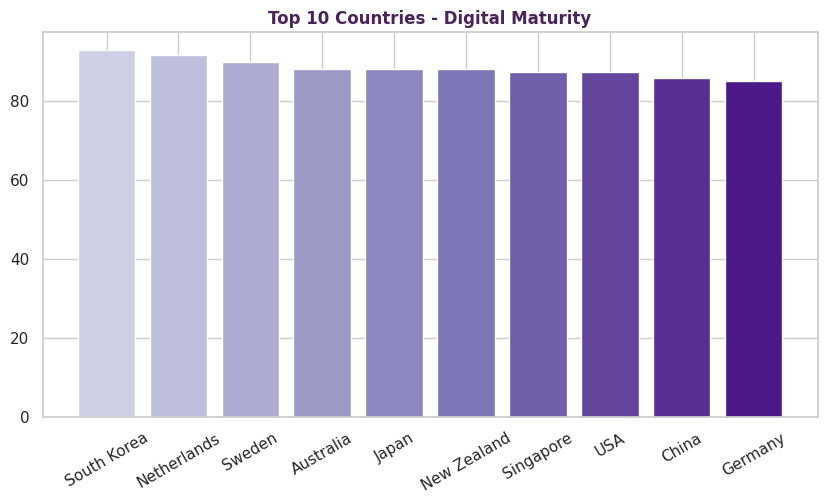

In [ ]:
# ===========================================================================================================================
# TOP 10 COUNTRIES BY DIGITAL MATURITY
# ===========================================================================================================================

top_country = df_country.sort_values('digital_maturity_index', ascending=False).head(10)

plt.figure(figsize=(10,5))

plt.bar(top_country['country'],
        top_country['digital_maturity_index'],
        color=CLR_GRADIENT(10))

plt.title('Top 10 Countries - Digital Maturity',
          color=CLR_DARK, fontweight='bold')

plt.xticks(rotation=30)

plt.show()

Berdasarkan grafik tersebut, terlihat bahwa **Korea Selatan** memiliki tingkat digital maturity tertinggi di antara 10 negara yang ditampilkan, diikuti oleh **Belanda** dan **Swedia**. Secara umum, semua negara dalam daftar memiliki tingkat kematangan digital yang tinggi (di atas 85), sehingga perbedaannya relatif kecil. Negara seperti **Jerman** dan **China** berada di posisi bawah dalam daftar ini, namun tetap menunjukkan tingkat digital maturity yang kuat. Hal ini menunjukkan bahwa negara-negara tersebut secara keseluruhan sudah cukup maju dalam transformasi digital, dengan hanya sedikit variasi antar negara.

In [ ]:
# ===========================================================================================================================
# COUNTRY-LEVEL AI ADOPTION ANALYSIS
# ===========================================================================================================================

import numpy as np
import matplotlib.pyplot as plt

CLR_PRIMARY = '#6A0DAD'
CLR_GRADIENT = lambda n: plt.cm.Purples(np.linspace(0.35, 0.95, n))


# ===========================================================================================================================
# GROUPBY COUNTRY
# ===========================================================================================================================

country_avg = df_clean.groupby('country').agg(
    adoption=('ai_adoption_rate', 'mean'),
    productivity=('productivity_change_percent', 'mean'),
    automation=('task_automation_rate', 'mean'),
    jobs_displaced=('jobs_displaced', 'mean'),
    jobs_created=('jobs_created', 'mean'),
    companies=('country', 'count')
).reset_index()


# ===========================================================================================================================
# INTERACTIVE MAP (PLOTLY)
# ===========================================================================================================================
PLOTLY = True
if PLOTLY:

    import plotly.express as px

    fig = px.choropleth(
        country_avg,
        locations='country',
        locationmode='country names',
        color='adoption',
        hover_name='country',

        hover_data={
            'adoption': ':.1f',
            'productivity': ':.1f',
            'automation': ':.1f',
            'jobs_displaced': ':.1f',
            'jobs_created': ':.1f',
            'companies': ':,'  # jumlah data
        },

        color_continuous_scale='Purples',
        title='🌍 Global AI Adoption Rate by Country (2023–2026 Average)',
        labels={'adoption': 'Avg Adoption %'}
    )

    fig.update_layout(
        title_font_size=18,
        title_font_color='#4a235a',
        height=520,
        geo=dict(
            showframe=False,
            showcoastlines=True,
            projection_type='natural earth'
        ),
        coloraxis_colorbar=dict(
            title='AI Adoption %',
            ticksuffix='%'
        )
    )

    fig.show()


# ===========================================================================================================================
# FALLBACK BAR CHART (JIKA PLOTLY TIDAK ADA)
# ===========================================================================================================================

else:

    top20 = country_avg.sort_values('adoption', ascending=True).tail(20)

    plt.figure(figsize=(10, 7))

    plt.barh(
        top20['country'],
        top20['adoption'],
        color=CLR_GRADIENT(len(top20)),
        edgecolor='white',
        linewidth=0.5
    )

    plt.title('🌍 Top 20 Countries by AI Adoption Rate',
              fontsize=14, fontweight='bold', color='#4a235a')

    plt.xlabel('Average AI Adoption Rate (%)')
    plt.ylabel('Country')

    # value labels
    for i, v in enumerate(top20['adoption']):
        plt.text(v + 0.3, i, f'{v:.1f}%', va='center', fontsize=9, color='#4a235a')

    plt.tight_layout()
    plt.show()

Peta global adopsi Artificial Intelligence (AI) menunjukkan adanya dua kondisi utama yang berbeda di berbagai negara. Di satu sisi, negara-negara dengan pendapatan tinggi atau *high-income economies* masih mendominasi tingkat adopsi AI. Negara seperti Amerika Serikat, negara-negara di Eropa Barat, Jepang, dan Korea Selatan memiliki keunggulan karena didukung oleh infrastruktur digital yang sangat kuat, seperti jaringan internet berkecepatan tinggi, sistem cloud computing yang matang, serta pusat data yang sudah berkembang pesat. Selain itu, tingginya investasi di bidang riset dan teknologi, ketersediaan tenaga ahli AI, serta dukungan kebijakan pemerintah membuat teknologi AI lebih cepat diadopsi di berbagai sektor seperti keuangan, kesehatan, industri manufaktur, hingga layanan publik.

Di sisi lain, negara-negara dengan ekonomi menengah seperti India, Brasil, dan Indonesia menunjukkan pola yang berbeda, yaitu bukan menjadi yang tertinggi dalam jumlah adopsi AI, tetapi mengalami pertumbuhan yang jauh lebih cepat. Perkembangan ini didorong oleh transformasi digital yang sangat pesat, meningkatnya jumlah startup teknologi, serta tingginya penggunaan internet dan perangkat mobile di masyarakat. Selain itu, populasi yang besar juga menjadi faktor penting karena menciptakan ekosistem data yang sangat potensial untuk pengembangan AI. Hal ini menunjukkan bahwa meskipun secara posisi masih tertinggal dari negara maju, negara berkembang sedang bergerak cepat untuk mengejar ketertinggalan tersebut.

Secara keseluruhan, peta ini menegaskan bahwa lanskap adopsi AI di dunia tidak bersifat tetap, melainkan terus berubah seiring waktu. Negara yang saat ini memimpin belum tentu akan selalu berada di posisi teratas, karena perkembangan teknologi sangat dipengaruhi oleh inovasi, investasi, dan kebijakan di masing-masing negara. Dengan demikian, dunia AI dapat dipahami sebagai ekosistem yang dinamis, di mana kecepatan adaptasi menjadi faktor yang sama pentingnya dengan tingkat kemajuan saat ini.